In [43]:
## SAVING FILES EXMAPLE

# aggregated_hourly = filtered_output_root_folder / "final_aggregated/services_hourly.parquet"
# con.execute(f"COPY services_hourly_agg TO '{aggregated_hourly}' (FORMAT PARQUET)")
# print("Done! Saved as ", aggregated_hourly)

# Prior work insights:

Lei's:
- Goal: Predict edge based on Topological features only (excluding any geographical i.e. spatial and temporal information)
- Prediction Task: Monthly edge removal prediction (supervised binary classification defined as link prediction)
- Class imbalance strategy: random undersampling
- Dynamic network
- Brute force grid search 
- Models: XGBoost best (27 models evaluated)
- Lei's trained on non simultaneous (same time), to predict on same time, simultaneous trained on network on specific time (partially) to predict the remaining part. 
- Conclusion: Showed it's possible to do edge classification (link prediction) based on (local) topological features for fast changing networks
- Future work: suggests adding to their limited feature set in various ways
- My critique/takeaway: Monthly timeline

Merel's: 
- Goal: Attempted generalizability of Lei's work to edge classification and slower changing network 
- Prediction Task: Monthly binary edge classification of 'significantly' DELAYED trajectory (supervised binary classification as edge classification)
- Class imbalance strategy: Reclassification ground truth label per trajectory (aggregated trajectory) based on entire data distribution
- Excluded weights due to leakage; compensated by adding node measurements to capture station importance instead
- Static network -> assumed due to slow changing nature 
- RandomSearchCV 
- Models: LR,RF,DT,GB,AdaBoost,XGBoost
- Conclusion: Topology features showed limited performance
- Future work: suggested to include temporal, operational and environmental data, data limitation of monthly aggregation, ensemble models
- My critique/takeaway: Monthly timeline, data (station) aggregation strategy, class imbalance strategy unsuitable, static network representation, weights were most important feature in Lei's work

Brent's:
- Goal: integrate spatial temporal features into dynamic graph based models + temporal component on daily time scale trajectory DISRUPTIONS
- Prediction Task: Daily binary edge classification of CANCELLED trajectories 
- Class imbalance strategy: tree based models scale_pos_weight, DGNN = class weighted entropy loss, SMOTE rejected due to unsuitability
- Dynamic network 
- RandomSearchCV
- Models: LR, RF, GB, XGB, DGNN (proposed)
- Conclusion: Complexity of DGNN limited performance increase, bad absolute performance, weather features not relevant, feature selection issues (LSTM permutation importance)
- Future Work: Higher resolution meteorology data, feature selection methods for sequence and graph models (to increase XAI), full scale tests with external data
- My critique/takeaways: Weather dataset quality issues, limited performance increase vs huge complexity (computation and interpretability tradeoff), XGBoost similar so back to 

Ours: 
- Goal: Reevaluate Lei's generalizability of topological features for edge classification and evaluate operational (lag and preplanned schedule information) features, environmental features for tree based models.
- Prediction task: Hourly binary edge classification of DELAYED trajectories (i.e. predicting network state; will a trajectory be delayed or not (binary), for short term delay management)
- Class imbalance strategy: classification label definition (>0min passenger experience perpective), and tree based models scale_pos_weight
- Dynamic network, due to hourly granularity
- Hyperparameter: RandomSearchCV
- Conclusion: TBD, limitations
- Future work: TBD, limitations
- Motivation for work to tackle LIMITATIONS of prior work I propose: Hourly (Merel data limitation), Stop level trajectory aggregation (Merel data limitation), Redefined classification label (Merel imbalance strategy), back to tree based models (Brent's increased complexity but limited performance increase compared to XGB in most settings), higher resolution of meteorology data (Brent's weather data limitation)


NOTES TODO (ASK):

Requiring models that capture both -> do we need to prove dependency (how, by showing correlation with spatial and temporal columns?) pearson correlation in prior work seems not quite right
Correlation with temporal column?

Nonsim = robustness (train on history, predict future)
temporal features only lag features + (transformed) calender info enough? or require time series modeling?

Prediction task: want to add 'to what extent' (multiclass)

# Classification baseline models notebook

## Imports

In [44]:
# ============================================================================
# SECTION 1: IMPORTS
# ============================================================================
# Import all necessary libraries for model training, evaluation, and visualization

import os
import random
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, make_scorer, f1_score, precision_score, recall_score, classification_report, accuracy_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import seaborn as sns
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import roc_auc_score, balanced_accuracy_score

import matplotlib.pyplot as plt

import duckdb
######################

import sys
import random

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as ss

from tqdm import tqdm
# from imblearn.under_sampling import RandomUnderSampler
from xgboost import XGBClassifier
from sklearn.metrics import confusion_matrix,balanced_accuracy_score, mean_squared_error,r2_score,mean_absolute_error



import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import joblib 
from tqdm import tqdm
from scipy.stats import uniform, randint, loguniform

# --- Models ---
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from xgboost import XGBClassifier

# --- Preprocessing & Tuning ---
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline 
from sklearn.metrics import f1_score, roc_auc_score, balanced_accuracy_score

import shap



## Globals

In [45]:
# GLOBALS
snellius = False # Set True for snellius, False for local development
partition = "services_full" if snellius else "services_subset"

RANDOM_SEED = 88
run_analysis = False

In [46]:
# KEY POINT: These are NOT time series sequences. Instead:
# - Each row represents ONE TRAJECTORY on ONE HOUR ON A SPECIFIC DATE
import os
from pathlib import Path

if snellius is False:
    # Change later to snellius $HOME or whatever folder you want to work in
    target_root = Path(r"C:\Users\jialo\Desktop\MSc-DS-Thesis\MSc-Thesis-Repo\MSc-Thesis\Bao")

    # Check if it exists before moving
    if target_root.exists():
        os.chdir(target_root)
        print(f"✅ Success! Moved to: {Path.cwd()}")
    else:
        print(f"❌ Error: The folder '{target_root}' does not exist.")

✅ Success! Moved to: C:\Users\jialo\Desktop\MSc-DS-Thesis\MSc-Thesis-Repo\MSc-Thesis\Bao


In [47]:
if snellius is True:
    # Get the home directory path object
    home_dir = Path.home() 

    # Build a path to your code
    target_root = home_dir / "NS_Thesis"

    print(target_root)

In [48]:
project_root = target_root
final_data_root = project_root / "downloads/data/filtered/final_aggregated"
final_data_filepath = final_data_root / "final_dataset_with_operational.parquet"

media_folder = project_root / "media"
models_folder = project_root / "models"
results_folder = project_root / "results"

Connect duckDB database

In [49]:
## Connect to database
db_name = 'main_classifications.duckdb'

# Check before
print(f"Does file exist? {os.path.exists(db_name)}")

con = duckdb.connect(database='main_classifications.duckdb') 

# Optional: Explicitly cap RAM so DuckDB knows WHEN to start spilling
# (e.g., set to 70-80% of your actual machine RAM)
if snellius is False:
    con.execute("SET memory_limit='5GB'")   

Does file exist? True


## Feature lists

In [50]:
service_features = [
    'source', 'target', 'distance',
]

topology_features = [
    'total_services', 'src_degree', 'src_weighted_degree', 'src_avg_distance', 
    'tgt_degree', 'tgt_weighted_degree', 'tgt_avg_distance', 
    'common_neighbors', 'jaccard_coefficient', 'preferential_attachment', 
    'adamic_adar_index', 'resource_allocation_index',
]

weather_features = [
    'temperature_2m', 'rain', 'snowfall', 'snow_depth', 
    'wind_speed_10m', 'wind_gusts_10m', 'soil_temperature_0_to_7cm'
]

calendar_features = ['arrival_hour', 'is_holiday', 
 'service_year', 'service_month', 'day_of_week'
 ]

operational_features = ['rolling_prev_5_avg_delay',
 'hours_since_prev_service',
 'delta_hours_since_last_service',
 'delta_count_services_since_last_delay',
 'delta_hours_since_last_delayed_service',
 'total_last_services_count',
 'total_last_delayed_services_count',
 'ratio_last_delay'
 ]

non_numeric_features = ['source', 
    'target', 
    'service_date', 
    'train_type_counts', 
    'month_name', 
    'day_name']

all_features = service_features + topology_features + weather_features + calendar_features + operational_features

# multiclass dropped for now
target_features = ['target_binary']

features_to_drop = non_numeric_features + [
'total_departure_delay_minutes',
 'avg_departure_delay_minutes','total_delay_minutes',
 'avg_delay_minutes',
 'count_delayed_services',
 'count_delayed_departure_services',
 'ratio_departure_delayed',
 'ratio_arrival_delayed',
 'count_platform_changes',
 'target_multiclass'
 ]

In [51]:
con.execute("DROP VIEW IF EXISTS services_final")

In [52]:
# Convert your list into a comma-separated string for the SQL query
refined_drop_list = list(set(features_to_drop) - {'service_date'})
cols_to_exclude = ", ".join(refined_drop_list)


In [53]:
con.execute(f"""
    CREATE OR REPLACE VIEW services_final AS 
    SELECT * EXCLUDE ({cols_to_exclude})
    FROM read_parquet('{final_data_filepath}') 
    ORDER BY service_date ASC, arrival_hour ASC
""")

## Description dataset

### Column Features

FEATURE LISTS

service_features = [
    'source', 'target', 'distance',
]

topology_features = [
    'total_services', 'src_degree', 'src_weighted_degree', 'src_avg_distance', 
    'tgt_degree', 'tgt_weighted_degree', 'tgt_avg_distance', 
    'common_neighbors', 'jaccard_coefficient', 'preferential_attachment', 
    'adamic_adar_index', 'resource_allocation_index',
]

weather_features = [
    'temperature_2m', 'rain', 'snowfall', 'snow_depth', 
    'wind_speed_10m', 'wind_gusts_10m', 'soil_temperature_0_to_7cm'
]

calendar_features = ['arrival_hour', 'is_holiday', 'month_name', 'day_name', 
 'service_year',
 'service_month',
 'day_of_week'
 ]

operational_features = ['rolling_prev_5_avg_delay',
 'hours_since_prev_service',
 'delta_hours_since_last_service',
 'delta_count_services_since_last_delay',
 'delta_hours_since_last_delayed_service',
 'total_last_services_count',
 'total_last_delayed_services_count',
 'ratio_last_delay'
 ]

target_features = ['target_binary', 'target_multiclass']

features_to_drop_list = ['service_date', 'total_departure_delay_minutes',
 'avg_departure_delay_minutes','total_delay_minutes',
 'avg_delay_minutes',
 'count_delayed_services','ratio_departure_delayed',
 'ratio_arrival_delayed',
 'count_platform_changes',
 'train_type_counts',
 ]

['source',
 'target',
 'service_date',
 'arrival_hour',
 'earliest_departure_hour',
 'distance',
 'total_departure_delay_minutes',
 'avg_departure_delay_minutes',
 'count_delayed_departure_services',
 'total_delay_minutes',
 'avg_delay_minutes',
 'count_delayed_services',
 'total_services',
 'ratio_departure_delayed',
 'ratio_arrival_delayed',
 'count_platform_changes',
 'train_type_counts',
 'src_degree',
 'src_weighted_degree',
 'src_avg_distance',
 'tgt_degree',
 'tgt_weighted_degree',
 'tgt_avg_distance',
 'common_neighbors',
 'jaccard_coefficient',
 'preferential_attachment',
 'adamic_adar_index',
 'resource_allocation_index',
 'temperature_2m',
 'rain',
 'snowfall',
 'snow_depth',
 'wind_speed_10m',
 'wind_gusts_10m',
 'soil_temperature_0_to_7cm',
 'is_holiday',
 'target_binary',
 'target_multiclass',
 'count_intercity',
 'count_sprinter',
 'count_other_trains',
 'month_name',
 'day_name',
 'rolling_prev_5_avg_delay',
 'hours_since_prev_service',
 'delta_hours_since_last_service',
 'delta_count_services_since_last_delay',
 'delta_hours_since_last_delayed_service',
 'total_last_services_count',
 'total_last_delayed_services_count',
 'ratio_last_delay',
 'service_year',
 'service_month',
 'day_of_week']

In [54]:
if run_analysis:
	display(con.execute("DESCRIBE services_final").df().column_name.tolist())

In [55]:
if run_analysis:
	display(con.execute("DESCRIBE services_final").df())

### Class balance analysis

Classes are currently based off avg delay / services on trajectory


trajectories_no_delay: The number of rows (route/hour trajectories) where zero scheduled trains were late.

trajectories_with_delay: The number of rows where at least one scheduled train experienced a delay.

total_individual_services: The grand total of all trains scheduled across the entire dataset (the sum of the total_services column).

total_delayed_services: The actual number of late trains (the sum of the count_delayed_services column).

In [56]:
if run_analysis:
	# Query to calculate trajectory-level stats
	class_balance_stats = con.execute("""
		SELECT 
			COUNT(*) FILTER (WHERE target_binary = 0) as trajectories_no_delay,
			COUNT(*) FILTER (WHERE target_binary = 1) as trajectories_with_delay,
			SUM(total_services) as total_individual_services,
			SUM(count_delayed_services) as total_delayed_services
		FROM services_final
	""").df()

	print(class_balance_stats)

In [57]:
if run_analysis:
	# Data for the pie chart
	labels = ['Serivces on trajectory without delay', 'Services on trajectory with delay']
	sizes = [class_balance_stats.iloc[0]['trajectories_no_delay'], class_balance_stats.iloc[0]['trajectories_with_delay']]
	colors = ['lightgreen', 'salmon']

	# Plot the pie chart
	plt.figure(figsize=(8, 6))
	plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=90, colors=colors)
	plt.title('Planned Services on Trajectories with and without delay (Binary Target)')
	plt.show()

In [58]:
if run_analysis:
	# Query the existing target_multiclass column
	multiclass_distribution = con.execute("""
		SELECT 
			target_multiclass, 
			COUNT(*) AS total_trajectories,
			ROUND(100.0 * COUNT(*) / SUM(COUNT(*)) OVER (), 2) AS percentage
		FROM services_final
		GROUP BY target_multiclass
		ORDER BY target_multiclass
	""").df()

	print(multiclass_distribution)

In [59]:
if run_analysis:
	# 1. Force the DataFrame to follow the 0, 1, 2, 3 order
	multiclass_distribution = multiclass_distribution.sort_values('target_multiclass')

	# 2. Extract sizes based on that guaranteed order
	sizes = multiclass_distribution['total_trajectories'].tolist()

	# 3. Match labels and colors to that exact sequence
	labels = [
		'On-time/Early (-inf, 0] (0)', 
		'Short (0, 30) min (1)', 
		'Medium [30, 60) min (2)', 
		'Severe [60, inf) min (3)'
	]
	colors = ['lightgreen', 'salmon', 'orange', 'gold']

	plt.figure(figsize=(10, 7))

	plt.pie(sizes, 
			labels=labels, 
			autopct='%1.1f%%', 
			startangle=140, 
			colors=colors, 
			pctdistance=0.85,
			counterclock=False) 

	plt.title('Distribution of Trajectory Delay Classes (Multiclass Target)')
	plt.tight_layout()
	plt.show()

### Stations

Inclusion of ALL trains with NS label as company (Intercity, Sprinter etc.) + filtering down to NL stations resulted in 307 stations in the final services dataset

In [60]:
if run_analysis:
	# Query to get the total count of unique stations
	unique_stations_count = con.execute("""
	    SELECT count(DISTINCT station) 
	    FROM (
	        SELECT source AS station FROM services_final
	        UNION 
	        SELECT target AS station FROM services_final
	    )
	""").fetchone()[0]

	print(f"Total unique stations: {unique_stations_count}")

## Full dataset

In [63]:
con.execute(f"DROP TABLE IF EXISTS {partition}")

In [64]:
if snellius is True:
    # This is often the cleanest 'one-liner' that is Arrow-aware
	con.execute(f"""
			CREATE TABLE {partition} AS
			SELECT * FROM services_final
		""")

## SUBSET of whole dataset for testing, replace later by full

In [65]:
# Connect to your existing duckdb connection 'con'
# We add an ORDER BY to make chronological splitting easier later

if snellius is False:
    con.execute(f""" 
		CREATE OR REPLACE TABLE {partition} AS
		SELECT * FROM services_final
		WHERE service_date >= '2023-12-31' 
		AND service_date <= '2024-01-01'
	""")

    # Verify the count
    count = con.execute(f"SELECT count(*) FROM {partition}").fetchone()[0]
    print(f"Subset created with {count} rows.")


Subset created with 18896 rows.


In [ ]:
service_df = con.execute(f"""SELECT * FROM {partition}""").df()
service_df
print("SUCCESFULLY transformed full dataset to df")

,service_date,arrival_hour,earliest_departure_hour,distance,total_services,src_degree,src_weighted_degree,src_avg_distance,tgt_degree,tgt_weighted_degree,...,hours_since_prev_service,delta_hours_since_last_service,delta_count_services_since_last_delay,delta_hours_since_last_delayed_service,total_last_services_count,total_last_delayed_services_count,ratio_last_delay,service_year,service_month,day_of_week
0,2023-12-31,1,1,16,2,5,6,47.166667,4,5,...,20.0,20.0,6,45.0,1,1,1.00,2023,12,0
1,2023-12-31,1,1,15,1,5,8,20.833333,3,3,...,2.0,2.0,1,2.0,2,1,0.50,2023,12,0
2,2023-12-31,1,1,29,1,4,6,39.000000,2,2,...,2.0,2.0,1,2.0,4,2,0.50,2023,12,0
3,2023-12-31,1,1,14,1,4,4,22.000000,2,2,...,2.0,2.0,1,2.0,2,1,0.50,2023,12,0
4,2023-12-31,1,1,29,1,5,6,47.166667,3,4,...,2.0,2.0,1,2.0,2,1,0.50,2023,12,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18891,2024-01-01,23,23,7,4,4,16,12.000000,6,16,...,1.0,1.0,1,1.0,4,1,0.25,2024,1,1
18892,2024-01-01,23,23,4,2,8,16,23.000000,4,8,...,1.0,1.0,2,2.0,2,1,0.50,2024,1,1
18893,2024-01-01,23,23,3,1,4,4,13.000000,8,20,...,1.0,1.0,4,4.0,1,1,1.00,2024,1,1
18894,2024-01-01,23,23,1,2,10,24,16.800000,4,8,...,1.0,1.0,2,2.0,2,1,0.50,2024,1,1


## Class balance (training)

In [69]:
# 1. Get the counts dataframe
balance_df = con.execute("""
    SELECT 
        target_binary, 
        COUNT(*) as count
    FROM services_final 
    WHERE service_year < 2024 
    GROUP BY target_binary
""").df()

# 2. Extract counts (assuming 0 is Negative, 1 is Positive)
neg_count = balance_df.loc[balance_df['target_binary'] == 0, 'count'].values[0] # not delayed
pos_count = balance_df.loc[balance_df['target_binary'] == 1, 'count'].values[0] # delayed

# 3. Store the ratio in a variable
# XGBoost Formula: sum(negative instances) / sum(positive instances)
scale_pos_weight_value_train = neg_count / pos_count

print(f"Negative Count: {neg_count}")
print(f"Positive Count: {pos_count}")
print(f"Recommended scale_pos_weight: {scale_pos_weight_value_train:.2f}")

Negative Count: 12607025
Positive Count: 9863362
Recommended scale_pos_weight: 1.28


In [70]:
con.execute("""
    SELECT 
        target_binary, 
        COUNT(*) as count,
        COUNT(*) / (SELECT COUNT(*) FROM services_final WHERE service_year < 2024) as ratio
    FROM services_final 
    WHERE service_year < 2024 
    GROUP BY target_binary
""").df()

,target_binary,count,ratio
0,0,12607025,0.561051
1,1,9863362,0.438949


56,1% 43,9%

## Initialize models

### Hyperparam search space
NOTE: We adopt best param of prior work instead for now 

But be aware of different data (distribution and class balance)

In [71]:
# # Hyperparameter grids for baseline models (adapted from brent)
# param_grid_lr = {
#         'C': [0.001, 0.01, 0.1, 1, 10, 100],
#         'penalty': ['l1', 'l2', 'elasticnet'],
#         'solver': ['liblinear', 'saga', 'newton-cg'],
#     }

# param_grid_rf = {
#         'n_estimators': [100, 200, 500, 1000],
#         'max_features': ['auto', 'sqrt', 'log2'],
#         'max_depth': [10, 20, 30, None],
#         'min_samples_split': [2, 5, 10],
#         'min_samples_leaf': [1, 2, 4],
#         'bootstrap': [True, False]
#     }

# param_grid_gbdt = {
#     'n_estimators': [100, 200, 300],
#     'learning_rate': [0.01, 0.1, 0.3],
#     'max_depth': [3, 5, 7],
#     'subsample': [0.6, 0.8, 1.0],
#     'min_samples_split': [2, 5, 10]
# }

# param_grid_xgb = {
#     'max_depth': [3, 5, 7],
#     'learning_rate': [0.01, 0.1, 0.3],      
#     'n_estimators': [100, 200, 300],
#     'subsample': [0.6, 0.8, 1.0],
#     'colsample_bytree': [0.6, 0.8, 1.0],
#     'scale_pos_weight': [1, sum(y == 0) / sum(y == 1)]
# }

# # Define scoring metrics for validation
# scoring = {
#     'f1': make_scorer(f1_score),
#     'precision': make_scorer(precision_score),
#     'recall': make_scorer(recall_score),
# }

In [72]:
print(service_df.isna().sum())

service_date                              0
arrival_hour                              0
earliest_departure_hour                   0
distance                                  0
total_services                            0
src_degree                                0
src_weighted_degree                       0
src_avg_distance                          0
tgt_degree                                0
tgt_weighted_degree                       0
tgt_avg_distance                          0
common_neighbors                          0
jaccard_coefficient                       0
preferential_attachment                   0
adamic_adar_index                         0
resource_allocation_index                 0
temperature_2m                            0
rain                                      0
snowfall                                  0
snow_depth                                0
wind_speed_10m                            0
wind_gusts_10m                            0
soil_temperature_0_to_7cm       

In [73]:
service_df['hours_since_prev_service'] = service_df['hours_since_prev_service'].fillna(0)

In [74]:
print(service_df.isna().sum())

service_date                              0
arrival_hour                              0
earliest_departure_hour                   0
distance                                  0
total_services                            0
src_degree                                0
src_weighted_degree                       0
src_avg_distance                          0
tgt_degree                                0
tgt_weighted_degree                       0
tgt_avg_distance                          0
common_neighbors                          0
jaccard_coefficient                       0
preferential_attachment                   0
adamic_adar_index                         0
resource_allocation_index                 0
temperature_2m                            0
rain                                      0
snowfall                                  0
snow_depth                                0
wind_speed_10m                            0
wind_gusts_10m                            0
soil_temperature_0_to_7cm       

Training Samples: 8855 | Testing Samples: 10041
Imbalance Ratio (Neg/Pos): 1.28

Starting Randomized Search and Saving Results to 'C:\Users\jialo\Desktop\MSc-DS-Thesis\MSc-Thesis-Repo\MSc-Thesis\Bao\models'...

--- Tuning Logistic_Regression ---
Fitting 5 folds for each of 10 candidates, totalling 50 fits
   > Best Params: {'clf__solver': 'liblinear', 'clf__penalty': 'l2', 'clf__C': 100}
   > Best CV Score: 0.6785

--- Tuning XGBoost ---
Fitting 5 folds for each of 10 candidates, totalling 50 fits


c:\Users\jialo\Desktop\MSc-DS-Thesis\MSc-Thesis-Repo\.venv\Lib\site-packages\xgboost\training.py:199: UserWarning: [12:58:01] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


   > Best Params: {'subsample': 0.8, 'scale_pos_weight': np.float64(1.278167119892791), 'n_estimators': 300, 'max_depth': 7, 'learning_rate': 0.01, 'colsample_bytree': 1.0}
   > Best CV Score: 0.6615

--- Tuning HistGradientBoosting ---
Fitting 5 folds for each of 10 candidates, totalling 50 fits
   > Best Params: {'max_leaf_nodes': 15, 'max_iter': 100, 'max_depth': 5, 'learning_rate': 0.1, 'l2_regularization': 0}
   > Best CV Score: 0.6736

Results saved to: C:\Users\jialo\Desktop\MSc-DS-Thesis\MSc-Thesis-Repo\MSc-Thesis\Bao\results\model_results.csv

--- Model Performance (Sorted by Balanced Accuracy) ---
               Model  Balanced Accuracy  F1 Score  AUC-ROC
             XGBoost           0.659013  0.579189 0.732344
 Logistic_Regression           0.658199  0.607987 0.731014
HistGradientBoosting           0.655477  0.574504 0.735909


C:\Users\jialo\AppData\Local\Temp\ipykernel_16908\1391445413.py:215: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Balanced Accuracy", y="Model", data=results_df, palette="viridis")


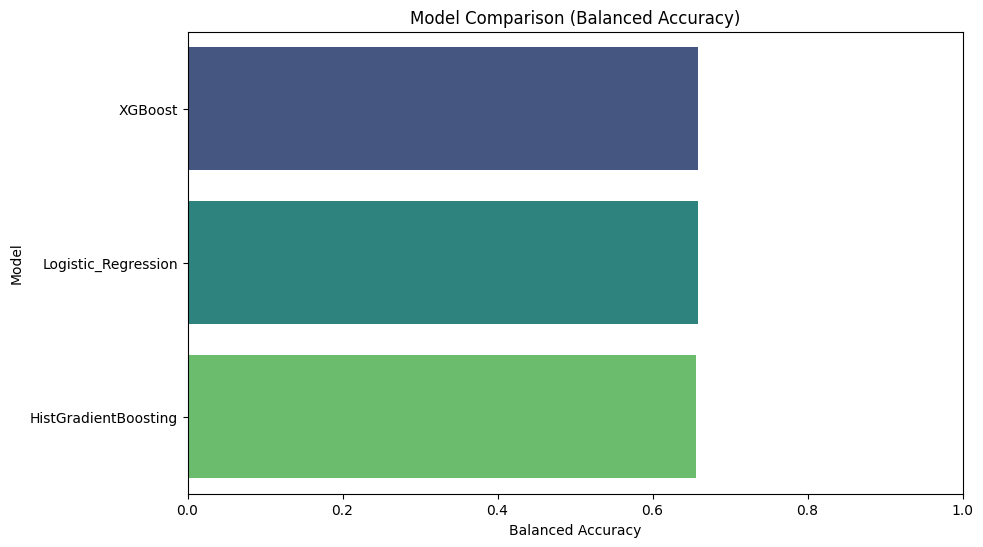


Winner: XGBoost (File: XGBoost_best.pkl)


In [76]:
# ==========================================
# 1. SETUP & DATA LOADING
# ==========================================

models_folder = models_folder
if not os.path.exists(models_folder):
    os.makedirs(models_folder)

# RANDOM SEED
RANDOM_SEED = 88

# ### ACTION REQUIRED: Load your dataset here ###

df = service_df
target_col = 'target_binary'
time_col = 'service_year'  

# ==========================================
# 2. TEMPORAL SPLIT & PREPROCESSING
# ==========================================

# 1. Sort by Time# Sort by Date first, then by Hour within that date
# df = df.sort_values(by=['service_date', 'arrival_hour']).reset_index(drop=True)
# df = df.drop(columns=['service_date'])

split_threshold = 2024  # Train on data before 2023, Test on 2024

# feature_cols = [c for c in df.columns if c not in [target_col, time_col]]

# 2. Encode Categoricals and bools
# bool_cols = df[feature_cols].select_dtypes(include=['bool']).columns
# for col in bool_cols:
#     df[col] = df[col].astype(int)

# 3. Create Split Mask
# train_mask = df[time_col] < split_threshold
# test_mask = df[time_col] >= split_threshold

# X_train = df.loc[train_mask, feature_cols]
# y_train = df.loc[train_mask, target_col]
# X_test = df.loc[test_mask, feature_cols]
# y_test = df.loc[test_mask, target_col]

# Load Train Split directly (Years < 2024)
X_train = con.execute(f"""
    SELECT * EXCLUDE (target_binary, service_year, service_date) 
    FROM {partition} 
    WHERE service_year < {split_threshold}
""").arrow().to_pandas(types_mapper=pd.ArrowDtype)

y_train = con.execute(f"""
    SELECT target_binary 
    FROM {partition} 
    WHERE service_year < {split_threshold}
""").arrow().to_pandas().values.ravel()

# Load Test Split directly (Year >= 2024)
X_test = con.execute(f"""
    SELECT * EXCLUDE (target_binary, service_year, service_date) 
    FROM {partition} 
    WHERE service_year >= {split_threshold}
""").arrow().to_pandas(types_mapper=pd.ArrowDtype)

y_test = con.execute(f"""
    SELECT target_binary 
    FROM {partition} 
    WHERE service_year >= {split_threshold}
""").arrow().to_pandas().values.ravel()

# 4. Calculate Imbalance ratio (for XGBoost)
scale_pos_weight_value = scale_pos_weight_value_train

print(f"Training Samples: {len(X_train)} | Testing Samples: {len(X_test)}")
print(f"Imbalance Ratio (Neg/Pos): {scale_pos_weight_value_train:.2f}")

# ==========================================
# 3. HYPERPARAMETER GRIDS (Updated)
# ==========================================

tscv = TimeSeriesSplit(n_splits=5) 

param_grids = {
    "Logistic_Regression": {
        # PIPELINE: Scales data ONLY for this model
        "model": Pipeline([
            ('scaler', StandardScaler()), 
            ('clf', LogisticRegression(class_weight='balanced', random_state=RANDOM_SEED, max_iter=1000))
        ]),
        # NOTE: Params must now use 'clf__' prefix to target the classifier step
        "params": {
            'clf__C': [0.001, 0.01, 0.1, 1, 10, 100],
            'clf__penalty': ['l2'], 
            'clf__solver': ['liblinear', 'saga'], 
        }
    },
    # "Random_Forest": {
    #     "model": RandomForestClassifier(class_weight='balanced', random_state=RANDOM_SEED, n_jobs=-1),
    #     "params": {
	# 		'n_estimators': [100, 200, 500, 1000],
	# 		'max_features': ['auto', 'sqrt', 'log2'],
	# 		'max_depth': [10, 20, 30, None],
	# 		'min_samples_split': [2, 5, 10],
	# 		'min_samples_leaf': [1, 2, 4],
	# 		'bootstrap': [True, False]
    #     }
    # },
    "XGBoost": {
        "model": XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=RANDOM_SEED, n_jobs=-1),
        "params": {
			'max_depth': [3, 5, 7],
			'learning_rate': [0.01, 0.1, 0.3],      
			'n_estimators': [100, 200, 300],
			'subsample': [0.6, 0.8, 1.0],
			'colsample_bytree': [0.6, 0.8, 1.0],
			'scale_pos_weight': [1, scale_pos_weight_value]
        }
    },
    "HistGradientBoosting": {
        "model": HistGradientBoostingClassifier(class_weight='balanced', random_state=RANDOM_SEED),
        "params": {
            'max_iter': [100, 200, 300],          # Equivalent to n_estimators
            'learning_rate': [0.01, 0.1, 0.3],
            'max_depth': [3, 5, 7, None],
            'max_leaf_nodes': [15, 32, 64],      # Critical for HistBoost
            'l2_regularization': [0, 0.1, 1.0, 10]
        }
    }
}


scoring = {
    'f1': make_scorer(f1_score),
    'precision': make_scorer(precision_score),
    'recall': make_scorer(recall_score),
    'roc_auc': make_scorer(roc_auc_score),
	'balanced_accuracy': make_scorer(balanced_accuracy_score)
}

# ==========================================
# 4. TUNING LOOP & SAVING
# ==========================================

results = []
print(f"\nStarting Randomized Search and Saving Results to '{models_folder}'...")


for name, config in param_grids.items(): 
    print(f"\n--- Tuning {name} ---")
    
    # Run Search
    search = RandomizedSearchCV(
        estimator=config["model"],
        param_distributions=config["params"],
        n_iter=10,           
        scoring=scoring,
        refit='f1',            
		cv=tscv, 
        verbose=1,
		n_jobs=4, 
		random_state=RANDOM_SEED,
        pre_dispatch='2*n_jobs'
    )
    
    search.fit(X_train, y_train)
    best_model = search.best_estimator_
    

    # --- PRINT BEST PARAMETERS (ADDED) ---
    print(f"   > Best Params: {search.best_params_}")
    print(f"   > Best CV Score: {search.best_score_:.4f}")

    # --- SAVE MODEL ---
    model_filename = f"{name}_best.pkl"
    joblib.dump(best_model, os.path.join(models_folder, model_filename))
    
    # Predict
    y_pred = best_model.predict(X_test)
    
    # Calculate Metrics
    f1 = f1_score(y_test, y_pred)
    bal_acc = balanced_accuracy_score(y_test, y_pred)
    
    try:
        y_prob = best_model.predict_proba(X_test)[:, 1]
        auc = roc_auc_score(y_test, y_prob)
    except:
        auc = 0
        
    results.append({
        "Model": name,
        "Balanced Accuracy": bal_acc,
        "F1 Score": f1,
        "AUC-ROC": auc,
        "Best Params": search.best_params_,
        "Saved File": model_filename
    })

# ==========================================
# 5. RESULTS SAVING & VISUALIZATION
# ==========================================

results_df = pd.DataFrame(results).sort_values(by="Balanced Accuracy", ascending=False)

# --- SAVE RESULTS TO CSV ---
results_path = os.path.join(results_folder, 'model_results.csv')
results_df.to_csv(results_path, index=False)
print(f"\nResults saved to: {results_path}")

print("\n--- Model Performance (Sorted by Balanced Accuracy) ---")
# Using tabulate format or simpler string conversion for readability
print(results_df[['Model', 'Balanced Accuracy', 'F1 Score', 'AUC-ROC']].to_string(index=False))

# Plotting Balanced Accuracy
plt.figure(figsize=(10, 6))
sns.barplot(x="Balanced Accuracy", y="Model", data=results_df, palette="viridis")
plt.title("Model Comparison (Balanced Accuracy)")
plt.xlim(0, 1.0) 
plt.show()

# Show report for winner
winner = results_df.iloc[0]
print(f"\nWinner: {winner['Model']} (File: {winner['Saved File']})")


In [77]:
# ==========================================
# 6. ROBUST SHAP ANALYSIS (Handles Pipelines & Raw Models)
# ==========================================

print("\n--- Running SHAP Analysis on the Winner ---")
results_path = os.path.join(results_folder, 'model_results.csv')
results_df = pd.read_csv(results_path)

# 1. Identify and Load the Winner
winner_row = results_df.iloc[0]
winner_name = winner_row['Model']
winner_file = winner_row['Saved File']
best_model = joblib.load(os.path.join(models_folder, winner_file))

print(f"Winner: {winner_name}")

# 2. Extract Model & Preprocessor Safely
# ---------------------------------------------------------
if hasattr(best_model, 'named_steps'):
    # CASE A: It is a Pipeline (e.g., Logistic Regression)
    print("   > Detected Pipeline structure.")
    preprocessor = best_model.named_steps['preprocessor'] if 'preprocessor' in best_model.named_steps else best_model.named_steps['scaler']
    model_step = best_model._final_estimator
    
    # Transform Test Data for SHAP
    X_test_transformed = preprocessor.transform(X_test)
    
    # Try to get feature names
    try:
        feature_names = preprocessor.get_feature_names_out()
    except:
        feature_names = X_test.columns
        
else:
    # CASE B: It is a Raw Model (e.g., HistGradient, XGBoost)
    print("   > Detected Raw Model structure.")
    preprocessor = None
    model_step = best_model
    
    # Use raw test data
    X_test_transformed = X_test
    feature_names = X_test.columns

# 3. Generate SHAP Values
# ---------------------------------------------------------
import shap

print(f"   > Explaining with {type(model_step).__name__}...")

try:
    if "Logistic" in winner_name or "Linear" in str(type(model_step)):
        # Linear Explainer (Needs background data)
        if preprocessor:
            X_train_transformed = preprocessor.transform(X_train)
        else:
            X_train_transformed = X_train
            
        # Summarize background to 100 samples to prevent crash
        masker = shap.maskers.Independent(data=X_train_transformed, max_samples=100)
        explainer = shap.LinearExplainer(model_step, masker=masker)
        shap_values = explainer.shap_values(X_test_transformed)

    elif "Hist" in winner_name:
        # HistGradientBoosting doesn't work with TreeExplainer efficiently
        # Use Permutation Explainer (Slow but universal)
        print("   > Note: Using PermutationExplainer (this is slower)...")
        
        # # Limit rows to 300 for speed
        # subset_test = X_test_transformed[:300]
        explainer = shap.TreeExplainer(model_step)
        shap_values = explainer(X_test_transformed)

    else:
        # XGBoost / Random Forest (Standard TreeExplainer)
        explainer = shap.TreeExplainer(model_step)
        shap_values = explainer.shap_values(X_test_transformed)

    # 4. Plot & Save
    # ---------------------------------------------------------
    plt.figure(figsize=(10, 8))
    
    # Handle SHAP return types
    if isinstance(shap_values, list):
        # Binary classification list [Neg, Pos] -> Plot Pos
        vals_to_plot = shap_values[1]
    elif hasattr(shap_values, 'values'):
        # PermutationExplainer returns an object with .values
        vals_to_plot = shap_values
    else:
        vals_to_plot = shap_values

    shap.summary_plot(vals_to_plot, X_test_transformed[:len(vals_to_plot)], feature_names=feature_names, show=False)
    
    save_path = os.path.join(results_folder, f"SHAP_Summary_{winner_name}.png")
    plt.savefig(save_path, bbox_inches='tight', dpi=300)
    plt.close()
    print(f"   > Saved SHAP plot to: {save_path}")

except Exception as e:
    print(f"   [!] SHAP Analysis Failed: {e}")
    print("       (This often happens with HistGradientBoosting due to library incompatibilities)")


--- Running SHAP Analysis on the Winner ---
Winner: XGBoost
   > Detected Raw Model structure.
   > Explaining with XGBClassifier...
   > Saved SHAP plot to: C:\Users\jialo\Desktop\MSc-DS-Thesis\MSc-Thesis-Repo\MSc-Thesis\Bao\results\SHAP_Summary_XGBoost.png


Lei's/Merels

1. Find best parameters per model, RandomizedSearchCV=10 TimeSeriesSplit n_split = data of years in training, on parameter grid (full train dataset)

2. Data Splitting: The "Trajectory" Split
Function: get_trajectory_slice

What they did: Instead of randomly splitting rows (e.g., taking 70% of all data points), they split by Trajectory (Source-Target pairs).

Train Set: All data for 70% of the routes (e.g., Amsterdam -> Utrecht).
Test Set: All data for the other 30% of the routes (e.g., Rotterdam -> Hague).

3. Feature Grouping (Ablation Study)
Functions: 

BTF (Binary Topological Features): Simple connection metrics (Common Neighbors, Jaccard).
WTF (Weighted Topological Features): Connection metrics that consider weight/intensity.
NCM (Node Centrality Metrics): Importance of the stations (Degree, Closeness).

4. Experiment A: Simultaneous Testing (The "Now" Test)
Function: simultaneous_test
Loop through every time horizon T. For each T, train on 70% of the edges in T and utilize 30% as test. This means for our hourly dataset too many -> can we randomly sample few hours in the dataset to test this instead of every hour? To check features without any temporal aspect. It eliminates the variable of time. If the model fails here, the features are useless. 
-> do we need randomundersampler?

model_null: Trained "dummy" on shuffled data. Real model atleast should be better than this random chance.

5. Experiment B: Non-Simultaneous Testing (The "Future" Test)
Function: nonsimultaneous_test

Train on Month X.
Test on Month X, Month X+1, Month X+2...

Testing Generalization across time

Can a model trained on January's network topology predict delays in March?

If metrics drop -> model drift, needs retraining. Tests robustness over time

6. Explainability: SHAP Analysis (on test sets) -> HOW it works
Function: all_shap_values

Workflow
Tune: Find best hyperparameters.
Split: Separate data by Route (Space).
Group: Pick a feature set (e.g., BTF).
Validate (Space, stimulous): Test on new routes in the same month.
Validate (Time, non stimulous): Test on new routes in future months.
Explain: Calculate SHAP to rank feature importance.

In [ ]:
# import sys
# import random
# import datetime
# import shap

# import pandas as pd
# import numpy as np
# import matplotlib.pyplot as plt
# import seaborn as sns
# import scipy.stats as ss

# from datetime import date
# from tqdm import tqdm
# from imblearn.under_sampling import RandomUnderSampler
# from xgboost import XGBClassifier
# from sklearn.metrics import confusion_matrix, balanced_accuracy_score, mean_squared_error, r2_score, mean_absolute_error

# sys.path.append('src')
# from plot_style import *

# def get_trajectory_slice(data, f_train_e=0.7, seed=30):
#     df = data
#     trajectories = list(set(df[['source', 'target']].itertuples(index=False, name=None)))
#     random.seed(seed)
#     train_size = int(f_train_e * len(trajectories))
#     random.shuffle(trajectories)
#     train_trajectories = set(trajectories[:train_size])
#     test_trajectories = set(trajectories[train_size:])
    
#     df_train = df.loc[df[['source', 'target']].apply(tuple, axis=1).isin(train_trajectories)].copy()
#     df_test = df.loc[df[['source', 'target']].apply(tuple, axis=1).isin(test_trajectories)].copy()
    
#     return df_train, df_test

# def df_to_XY(df, features, target='Significant Delay'):
#     X = df.loc[:, features].to_numpy()
#     y = df.loc[:, target].to_numpy()
#     return X, y

# def simultaneous_test(df_train, df_test, features, best_params, save=True, name=None):
#     if name is None:
#         name = ''.join([w[0] for w in features]) + '_simultaneous'
#     else:
#         name = name + '_simultaneous'
    
#     year_month_list = sorted(df_train['YearMonth'].unique())
#     res_df_test = df_test.copy()
#     res_df_test['simultaneous_pred'] = np.nan
#     res_df_test['simultaneous_null'] = np.nan
    
#     for year_month in tqdm(year_month_list):
#         X_train, y_train = df_to_XY(df_train[df_train['YearMonth'] == year_month], features)
#         ros = RandomUnderSampler()
#         X_train, y_train = ros.fit_resample(X_train, y_train)
#         X_test, y_test = df_to_XY(df_test[df_test['YearMonth'] == year_month], features)
        
#         y_train_null = y_train.copy()
#         np.random.shuffle(y_train_null)
        
#         model = XGBClassifier(**best_params)
#         model.fit(X_train, y_train)
#         model_null = XGBClassifier(**best_params)
#         model_null.fit(X_train, y_train_null)
        
#         y_pred = model.predict(X_test)
#         y_pred_null = model_null.predict(X_test)
        
#         res_df_test.loc[res_df_test['YearMonth'] == year_month, 'simultaneous_pred'] = y_pred
#         res_df_test.loc[res_df_test['YearMonth'] == year_month, 'simultaneous_null'] = y_pred_null
    
#     if save:
#         res_df_test.to_csv(f'./results_XGB/{name}.csv', index=False)
    
#     return res_df_test

# def nonsimultaneous_test(df_train, df_test, features, best_params, save=True, name=None):
#     if name is None:
#         name = ''.join([w[0] for w in features]) + '_nonsimultaneous'
#     else:
#         name = name + '_nonsimultaneous'
    
#     year_month_list = sorted(df_test['YearMonth'].unique())
#     preds = []
    
#     for year_month_train in tqdm(year_month_list):
#         X_train, y_train = df_to_XY(df_train[df_train['YearMonth'] == year_month_train], features)
#         ros = RandomUnderSampler()
#         X_train, y_train = ros.fit_resample(X_train, y_train)
        
#         y_train_null = y_train.copy()
#         np.random.shuffle(y_train_null)
        
#         model = XGBClassifier(**best_params)
#         model.fit(X_train, y_train)
#         model_null = XGBClassifier(**best_params)
#         model_null.fit(X_train, y_train_null)
        
#         for year_month_test in year_month_list:
#             if year_month_test < year_month_train:
#                 continue
#             X_test, y_test = df_to_XY(df_test[df_test['YearMonth'] == year_month_test], features)
#             y_pred = model.predict(X_test)
#             y_null = model_null.predict(X_test)
#             preds.append([year_month_train, year_month_test, y_test, y_pred, y_null])
    
#     if save:
#         import pickle
#         with open(f'./results_XGB/{name}.pkl', 'wb') as f:
#             pickle.dump(preds, f)
    
#     return preds

# def all_shap_values(df_train, df_test, features, best_params, save=True, name=None):
#     if name is None:
#         name = ''.join([w[0] for w in features]) + '_SHAP'
#     else:
#         name = name + '_SHAP'
    
#     def get_temporal_order(shap_list):
#         importance_array = []
#         for shap_values in shap_list:
#             array = -np.abs(shap_values).mean(axis=0)
#             ranks = ss.rankdata(array)
#             importance_array.append(ranks)
#         return np.array(importance_array)

#     shap_values_list = []
#     test_list = []
#     year_month_list = sorted(df_test['YearMonth'].unique())
    
#     for year_month in tqdm(year_month_list):
#         X_train, y_train = df_to_XY(df_train[df_train['YearMonth'] == year_month], features)
#         ros = RandomUnderSampler()
#         X_train, y_train = ros.fit_resample(X_train, y_train)
#         X_test, y_test = df_to_XY(df_test[df_test['YearMonth'] == year_month], features)
        
#         model = XGBClassifier(**best_params)
#         model.fit(X_train, y_train)
#         explainer = shap.TreeExplainer(model)
#         shap_values = explainer.shap_values(X_test)
        
#         test_list.append(pd.DataFrame(X_test, columns=features))
#         shap_values_list.append(shap_values)
    
#     if save:
#         import pickle
#         with open(f'./results_XGB/{name}.pkl', 'wb') as f:
#             pickle.dump((test_list, year_month_list, shap_values_list), f)
    
#     return test_list, year_month_list, shap_values_list

# def BTF(train, test):
#     name = 'NS_Classification_BTF'
#     features = ['CN', 'SA', 'JA', 'SO', 'HPI', 'HDI', 'LHNI', 'PA', 'AA', 'RA', 'LPI']
#     simultaneous_test(train, test, features, best_params, name=name)
#     nonsimultaneous_test(train, test, features, best_params, name=name)
#     all_shap_values(train, test, features, best_params, name=name)

# def WTF(train, test):
#     name = 'NS_Classification_WTF'
#     features = ['weighted_CN', 'weighted_SA', 'weighted_JA', 'weighted_SO', 'weighted_HPI', 
#                 'weighted_HDI', 'weighted_LHNI', 'weighted_PA', 'weighted_AA', 'weighted_RA', 'weighted_LPI']
#     simultaneous_test(train, test, features, best_params, name=name)
#     nonsimultaneous_test(train, test, features, best_params, name=name)
#     all_shap_values(train, test, features, best_params, name=name)

# def NCM(train, test):
#     name = 'NS_Classification_NCM'
#     features = ['source_closeness', 'target_closeness', 'source_degree', 'target_degree', 'source_strength', 'target_strength']
#     simultaneous_test(train, test, features, best_params, name=name)
#     nonsimultaneous_test(train, test, features, best_params, name=name)
#     all_shap_values(train, test, features, best_params, name=name)

# if __name__ == "__main__":
#     global best_params
#     best_params = {'lambda': 0.5650701862593042, 'alpha': 0.0016650896783581535,
#                    'colsample_bytree': 1.0, 'subsample': 0.5, 'learning_rate': 0.009,
#                    'n_estimators': 625, 'objective': 'binary:logistic', 'max_depth': 5, 'min_child_weight': 6}

#     data_path = '/Users/merelkamper/Documents/MSc Data Science/Thesis/MSc_thesis_code/features/monthly_features_per_trajectory.csv'
#     data = pd.read_csv(data_path)
#     data['YearMonth'] = pd.to_datetime(data['YearMonth']).dt.to_period('M')
    
#     train, test = get_trajectory_slice(data)
#     BTF(train, test)
#     WTF(train, test)
#     NCM(train, test)
